# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


/var/folders/hl/wc7w5mzn2dbclps0r962328h0000gn/T/ipykernel_43602/2893947107.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023-01-01', periods=numdates, freq='M')


<Axes: title={'center': 'Nitrate Level Over Time'}, xlabel='Year and Month', ylabel='Nitrate level (% of eutrophic value)'>

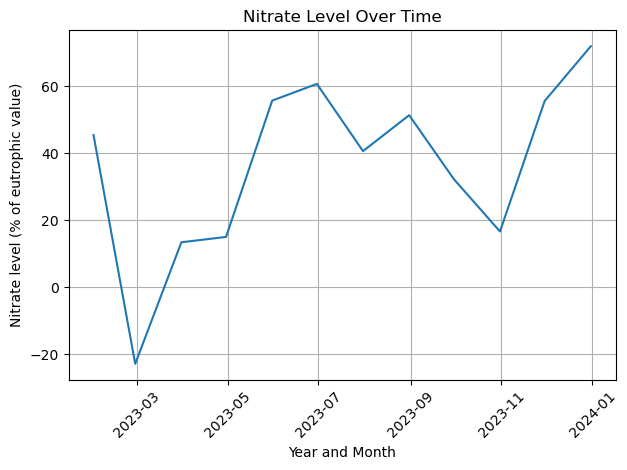

In [2]:
numdates = 12
np.random.seed(0)
datearray = pd.date_range(start='2023-01-01', periods=numdates, freq='M')

time_series = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
time_series_2 = 100 * (1 - (np.random.normal(size=numdates) / 8 + np.arange(numdates) / 16))


nitrate = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
ax = sns.lineplot(x=datearray, y=nitrate)
ax.set(title="Nitrate Level Over Time", xlabel="Year and Month", ylabel="Nitrate level (% of eutrophic value)")
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
ax.figure.tight_layout()
ax

<Axes: title={'center': 'Nitrate Level Over Time'}, xlabel='Year and Month', ylabel='Nitrate level (% of eutrophic value)'>

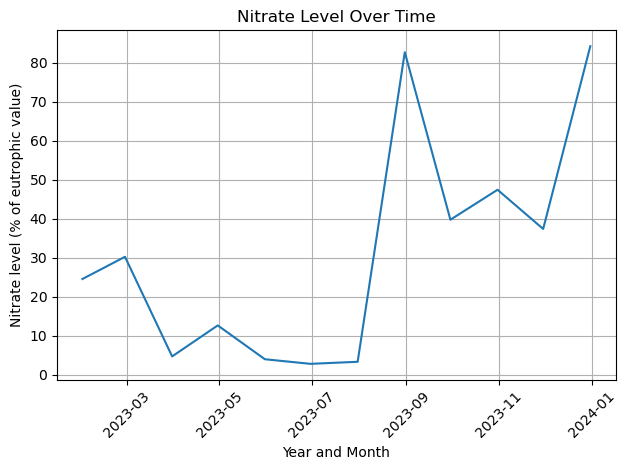

In [3]:
nitrate = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
ax = sns.lineplot(x=datearray, y=nitrate)
ax.set(title="Nitrate Level Over Time", xlabel="Year and Month", ylabel="Nitrate level (% of eutrophic value)")
ax.tick_params(axis='x', rotation=45)
ax.grid(True)
ax.figure.tight_layout()
ax

<Axes: >

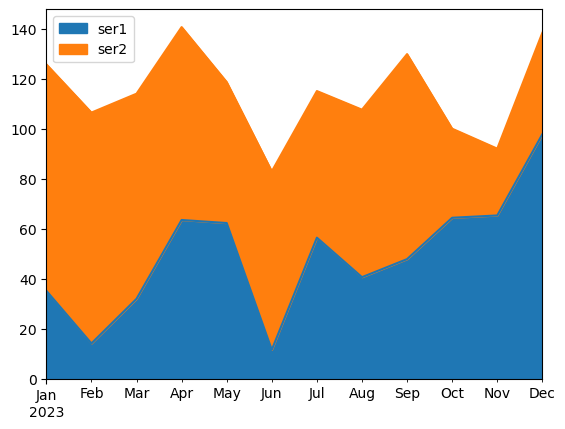

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

<Axes: title={'center': 'Area Plot of Two Time Series'}, xlabel='Date', ylabel='Value'>

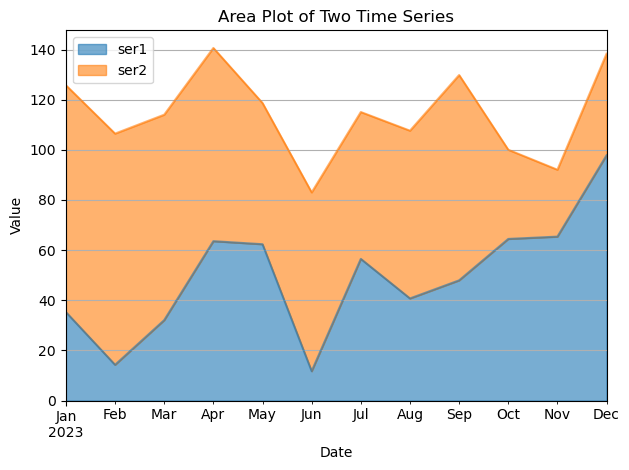

In [5]:
ax = df.plot.area(alpha=0.6, title="Area Plot of Two Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.grid(True)
ax.figure.tight_layout()
ax

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

/var/folders/hl/wc7w5mzn2dbclps0r962328h0000gn/T/ipykernel_43602/3980207304.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_index = pd.date_range(start="2022-01-01", periods=24, freq="M")


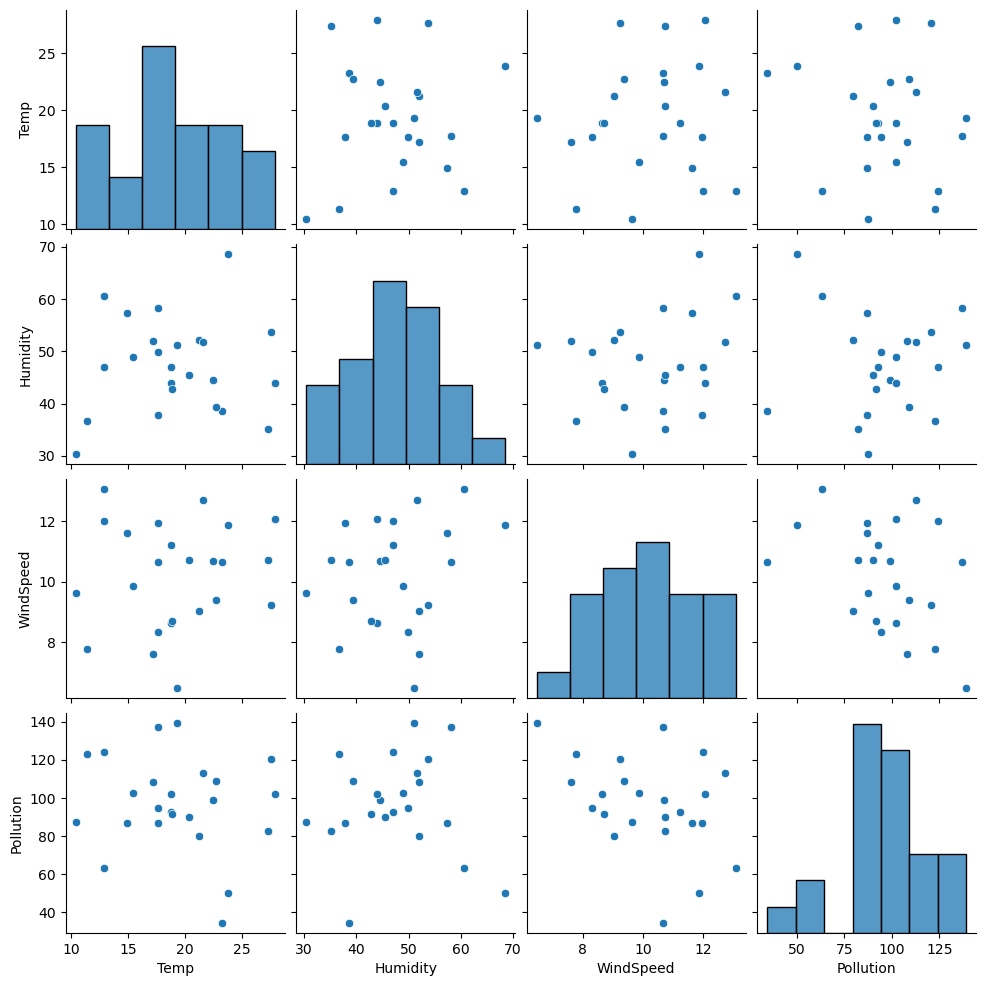

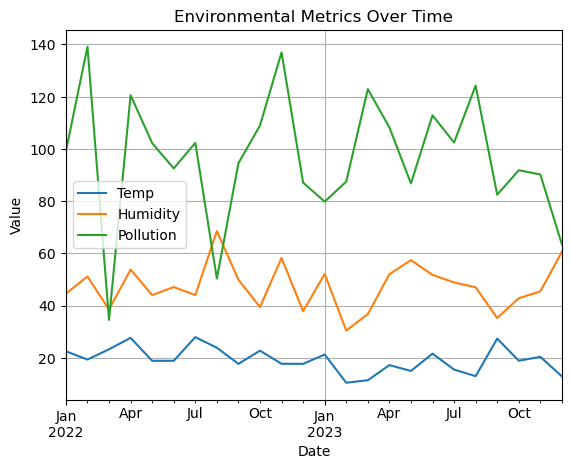

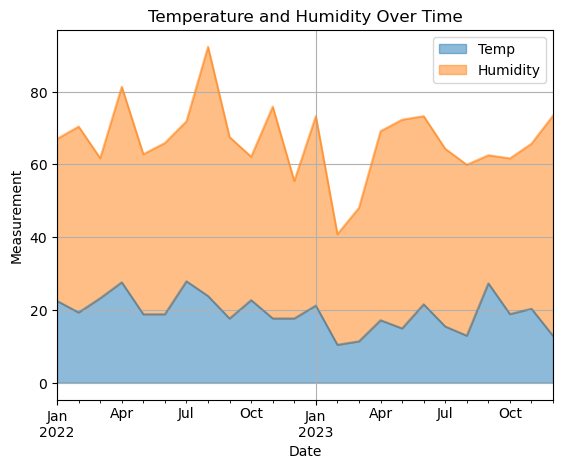

In [6]:
np.random.seed(42)
date_index = pd.date_range(start="2022-01-01", periods=24, freq="M")
data = {
    "Temp": np.random.normal(20, 5, size=24),
    "Humidity": np.random.normal(50, 10, size=24),
    "WindSpeed": np.random.normal(10, 2, size=24),
    "Pollution": np.random.normal(100, 25, size=24)
}
df_custom = pd.DataFrame(data, index=date_index)

# Calculate correlation matrix
correlation_matrix = df_custom.corr()

sns.pairplot(df_custom)

ax = df_custom[["Temp", "Humidity", "Pollution"]].plot(title="Environmental Metrics Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.grid(True)

ax = df_custom[["Temp", "Humidity"]].plot.area(alpha=0.5, title="Temperature and Humidity Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Measurement")
ax.grid(True)


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

In [7]:
data = pd.DataFrame({
    "Category": ["Product A", "Product B", "Product C", "Product D", "Product E"],
    "Value": [80, 55, 40, 65, 90]
})

In [8]:
data = data.sort_values("Value", ascending=True)

In [9]:
highlight = data["Category"] == "Product E"
colors = ["gray" if not val else "crimson" for val in highlight]

<Axes: title={'center': 'Customer Preference by Product (Highlighting Product E)'}, xlabel='Preference (%)'>

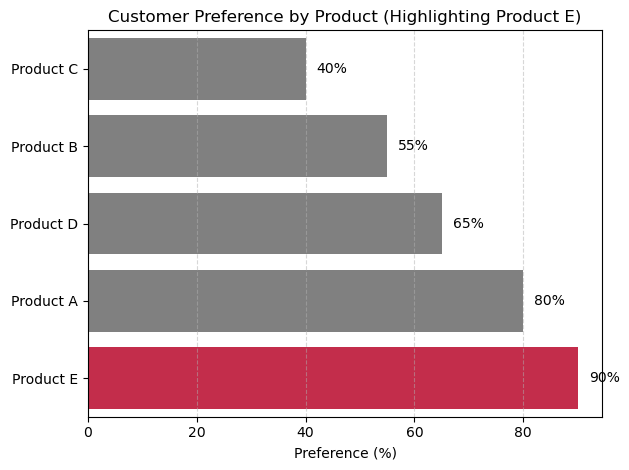

In [10]:
data["Highlight"] = data["Category"] == "Product E"
ax = sns.barplot(data=data, x="Value", y="Category", hue="Highlight", dodge=False, palette={True: "crimson", False: "gray"}, legend=False)
for i, (value, category) in enumerate(zip(data["Value"], data["Category"])):
    ax.text(value + 2, i, f"{value}%", va='center')


ax.set_title("Customer Preference by Product (Highlighting Product E)")
ax.set_xlabel("Preference (%)")
ax.set_ylabel("")

ax.grid(True, axis="x", linestyle="--", alpha=0.5)

ax.figure.tight_layout()
ax


### Bar Chart Features:

Horizontal bar chart sorted by value

Product E highlighted in red to emphasize its standout performance

Annotations added directly to bars for clarity

Clean formatting with gridlines and labels

This type of visual is excellent for:

Emphasizing outliers or top performers

Quickly comparing values

Making charts presentation-ready with minimal visual clutter